# Regression Modeling with BGC Argo Data

This workbook introduces basic concepts behind training a machine learning regression model using BGC Argo data. 

Our example application is to estimate a nitrate record along the trajectory of a glider from the [California Underwater Glider Network](https://globalocean.noaa.gov/project/california-underwater-glider-network/), which provides subsurface measurements of temperature, salinity, and and oxygen in the California Current Upwelling System (e.g. [Ren et al. 2025](https://doi.org/10.1016/j.pocean.2025.103473)). We demonstrate a workflow that queries nearby float data using [Argopy](https://argopy.readthedocs.io/en/latest/index.html) and implements random forest regression using the machine learning Python package [scikit-learn](https://scikit-learn.org/stable/user_guide.html). A similar ML application using BGC Argo data to estimate nitrate for two gliders is described in [Song et al. 2026](https://doi.org/10.1175/AIES-D-24-0048.1). 

![CUGN](https://spraydata.ucsd.edu/assets/img/cugn-map-680-470.jpg)
</br><i>Image source: https://spraydata.ucsd.edu/</i>
</br></br>
<i>Created by Sangmin Song and Alison Gray for the 2026 GO-BGC Data Workshop</i> 

### Learning Objectives 
At the end of this tutorial, participants should be able to:
- Understand how to train a simple regressor ([random forest](https://doi.org/10.1023/A:1010933404324)) on Argo data using scikit-learn
- Understand the purpose of model cross-validation and its sensitivity to type of data splitting 
- Understand the difference between model parameters and hyperparameters

### Python packages

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
from datetime import datetime

import matplotlib.pyplot as plt
from cmocean import cm as cmo
from cartopy import crs as ccrs

from scipy.stats import iqr
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Most of our custom functions live in a separate file `argotools.py` (open in another tab to follow along), which we import as `mod_argo`. 

In [ ]:
import argotools as mod_argo

# default Jupyterhub shared data folder
data_path = '/home/jovyan/shared/go-bgc-2026/data/machine_learning_tutorial/mldata_'

# 1. Data setup

The quality-controlled glider data are freely available through [CUGN](https://spraydata.ucsd.edu/projects/cugn/#about-project-dataset). The dataset uploaded for you represents one trajectory from CUGN Line 66 over the year 2022. 

The Argo data in this notebook can be downloaded using the Python package [Argopy](https://argopy.readthedocs.io/en/latest/), which offers many other utilities that are well-documented on their website. 

## 1.0 Argopy data import (option to skip)
To use data that has already been downloaded (recommended for demo), skip to the next section 1.1.

In [9]:
import argopy

# Set to False to avoid JupyterHub crashing with multiple users.
rerun_Argopy = False
rerun_save = False

In [10]:
# Query data around the mooring
if rerun_Argopy:
      argopy.set_options(src='erddap')  # Ifremer database, updated daily
      # Format: [lon_min, lon_max, lat_min, lat_max, pres_min, pres_max, datim_min, datim_max]
      BOX = [-140, -100, 15, 55, 0, 500, '2014-01-01', '2025-12-31']
      
      # Construct an Argopy DataFetcher object to query data
      fetcher = argopy.DataFetcher(ds='bgc', mode='expert', params='all',
                        measured=['NITRATE', 'DOXY'],
                        parallel=True, progress=True,
                        chunks_maxsize={'time': 30},
                        )
      bgc_fetcher = fetcher.region(BOX).load()

      # Returns xr Dataset with point observations as dimension
      bgc_profiles = bgc_fetcher.data.argo.point2profile();
      bgc_profiles = bgc_profiles.assign_attrs(raw_attrs = '', Fetched_uri='') # simplify for save

      # Store index and domain
      bgc_index = bgc_fetcher.index
      bgc_domain = bgc_fetcher.domain 

In [11]:
if rerun_Argopy:
    argoDF = mod_argo.create_argo_dataframe(bgc_profiles, 
                                                bgc_list = ['nitrate', 'oxygen'])
    qc_cols = ['temperature_qc', 'salinity_qc', 'pressure_qc', 'time_qc', 'position_qc', 'nitrate_qc', 'oxygen_qc'] 
    argoDF_QC = mod_argo.filter_qc_flags(argoDF, qc_vars=qc_cols, use_flags=['1', '2', '5', '8'])
    argoDF_QC = mod_argo.expand_datetime(argoDF_QC)

    # Choose spatial bounds and pressure limits 
    pres_lims = [0,500]
    box_lims = [-127, -121, 34, 38]
    argoDF_valid = argoDF_QC[(argoDF_QC.pressure > pres_lims[0]) & (argoDF_QC.pressure < pres_lims[1]) &
                        (argoDF_QC.longitude > box_lims[0]) & (argoDF_QC.longitude < box_lims[1]) & 
                        (argoDF_QC.latitude > box_lims[2]) & (argoDF_QC.latitude < box_lims[3])]
    # Add time features
    argoDF_valid['datetime'] = argoDF_valid['datetime'].astype('datetime64[ns]')
    argoDF_valid['linear_time'] = mod_argo.datetime2linear(argoDF_valid['datetime'], ref_time = '2014-01-01')
    argoDF_valid['ydcos'], argoDF_valid['ydsin'] = mod_argo.add_seasonal_sines(argoDF_valid['linear_time'])

if rerun_save:
    datetag = datetime.now().strftime("%Y%m%d")
    argoDF_valid.to_csv('../cugn66_argopy_2014-2025_qc1258_acc' + datetag + '.csv')

## 1.1 Exploring available data

We can take an initial look at the glider application before exploring what nearby Argo data are available. The glider data covers repeat transects on Line 66 over 2022, with samples at depths of 0–500 m. The provided data have already been quality-controlled and averaged to 10-m vertical bins ([Rudnick 2016](https://spraydata.ucsd.edu/projects/cugn/#about-project-dataset)). 

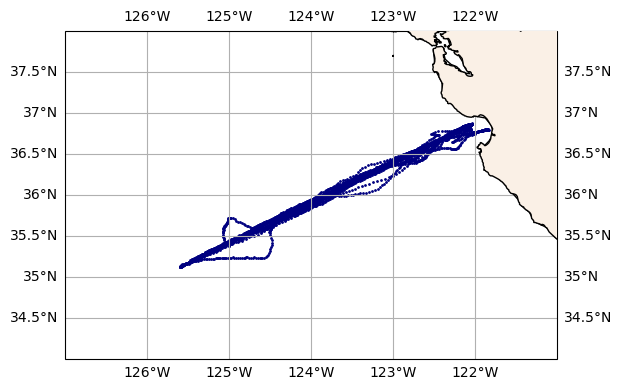

In [12]:
# Import Line 66 glider data
glider_traj0 =  pd.read_csv(data_path + 'CUGNline66_2022_traj0.csv', index_col=0)

# Average by profile/dive for plotting
gliderINDEX = glider_traj0.groupby('profile').first().dropna(subset=['temperature', 'salinity', 'oxygen'])

ax = mod_argo.map_study_region(gridlabel=True) # shortcut mapping function
ax.scatter(gliderINDEX.longitude, gliderINDEX.latitude, s=1, c='navy', transform=ccrs.PlateCarree())

To choose the spatiotemporal bounds of the Argo training data, we try to find a balance between
- data availability: how much data is available in the region(s) of interest?
- data specificity: how close are the data in space/time to the intended application?


For this demo, we'll use a simple latitude/longitude box around the glider and time range 2014–2025 to query a small Argo dataset that can be used to train multiple models quickly. For a true application, prior knowledge of the study region should guide what training data to consider. 

<div class="alert alert-block alert-info"> <b>Note:</b> Since ocean processes are nonstationary, a model should ideally include training observations close in space and time to the application. 

This is also part of the motivation behind the two-step clustering + regression approach used by a number of ocean models, in which observations are first divided into local groups by some physical and/or biogeochemical criteria, and separate regressions are trained for each group. </div> 

- [Kuusula and Stein 2018](https://pmc.ncbi.nlm.nih.gov/articles/PMC6304028/) - locally stationary window approach using Argo data (see also [Park et al. 2023](https://projecteuclid.org/journals/annals-of-applied-statistics/volume-17/issue-2/Spatiotemporal-local-interpolation-of-global-ocean-heat-transport-using-Argo/10.1214/22-AOAS1679.full))   
- [Gregor et al. 2019](https://gmd.copernicus.org/articles/12/5113/2019/gmd-12-5113-2019.pdf) - CSIR-ML6 ensemble model with two-step approach pCO2 estimation; discusses multiple algorithms

Total number of float profiles:  765
Time range: 	2014-01-18 to 2025-12-30
Latitude:	34.003 to 37.99695
Longitude:	-126.9924 to -121.3579


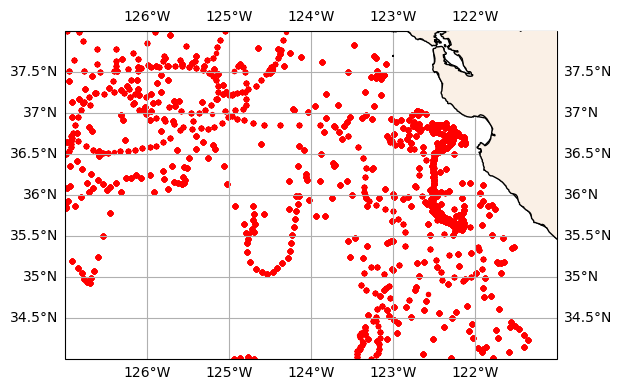

In [13]:
# Import quality-controlled argo data from Section 1.0
box_lims = [-127, -121, 34, 38]  # [lon_min, lon_max, lat_min, lat_max]
argoDF_QC = pd.read_csv(data_path + 'ARGO_2014-2025_qc1258.csv', index_col=0)

# Initial look at the Argo data
print('Total number of float profiles: ', len(argoDF_QC.profid.unique()))
mod_argo.print_float_bounds(argoDF_QC)
ax = mod_argo.map_study_region(gridlabel=True)
sca = ax.scatter(argoDF_QC.longitude, argoDF_QC.latitude, c='r', s=8, transform=ccrs.PlateCarree())

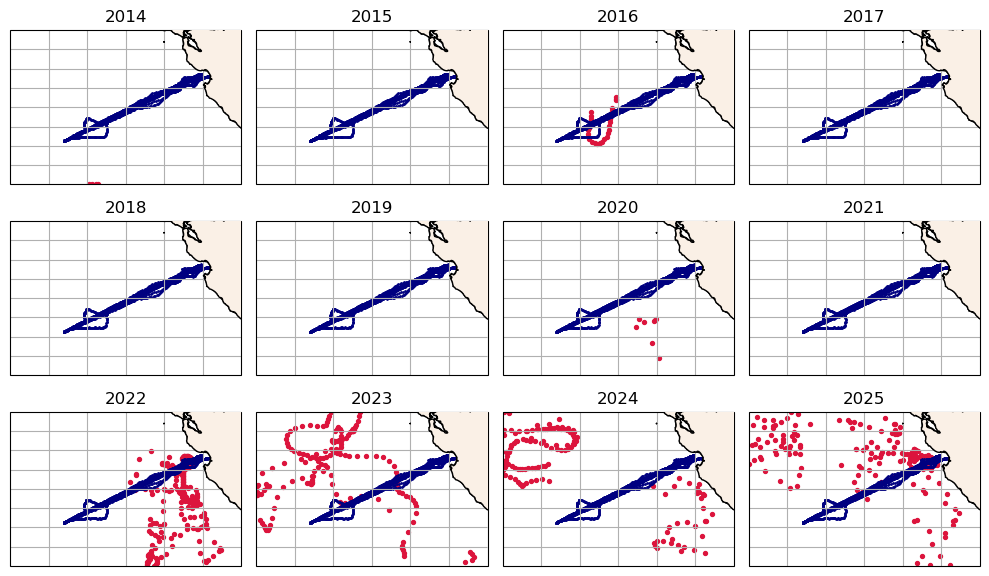

In [14]:
# Map distributions by year
fig, axs = plt.subplots(3,4, figsize=(10, 6), layout='tight', subplot_kw={'projection': ccrs.PlateCarree()})
for ind, ax in enumerate(axs.flatten()):
    year = 2014 + ind
    plot_data = argoDF_QC[(argoDF_QC.year == year)].groupby('profid').first()
    mod_argo.map_study_region(ax=ax, ax_lims=box_lims) # Base plotting function that sets up matplotlib axis
    ax.scatter(plot_data.longitude, plot_data.latitude, s=8, c='crimson', transform=ccrs.PlateCarree(), label='bgcArgo')
    ax.scatter(gliderINDEX.longitude, gliderINDEX.latitude, s=1, c='navy', transform=ccrs.PlateCarree(), label='glider (2020)')
    ax.set_title(year)


**Code activity:** print out how many profiles (identified by `profid`) and floats (identified by `wmoid`) are in the Argo dataset by year.

In [ ]:
# Add code here:


# === Key === 
# # Short answer
# print(argoDF_QC.groupby('profid').first().value_counts('year'))
# print(argoDF_QC.groupby('wmoid').first().value_counts('year'))

# # Alternative answer: 
# for yr in range(2014,2024):
#     print(yr, argoDF_QC[argoDF_QC.year==yr].profid.nunique())
# for yr in range(2014,2024):
#     print(yr, argoDF_QC[argoDF_QC.year==yr].wmoid.nunique())

### Statistical distributions in Argo and glider data

Ideally, the statistical properties of the training/validation/test data (Argo data) should match those of the application (glider data to 500 dbar). Our Argo training dataset has therefore been limited to the same pressure range. We can also plot the distributions between the two platforms for some of our input variables

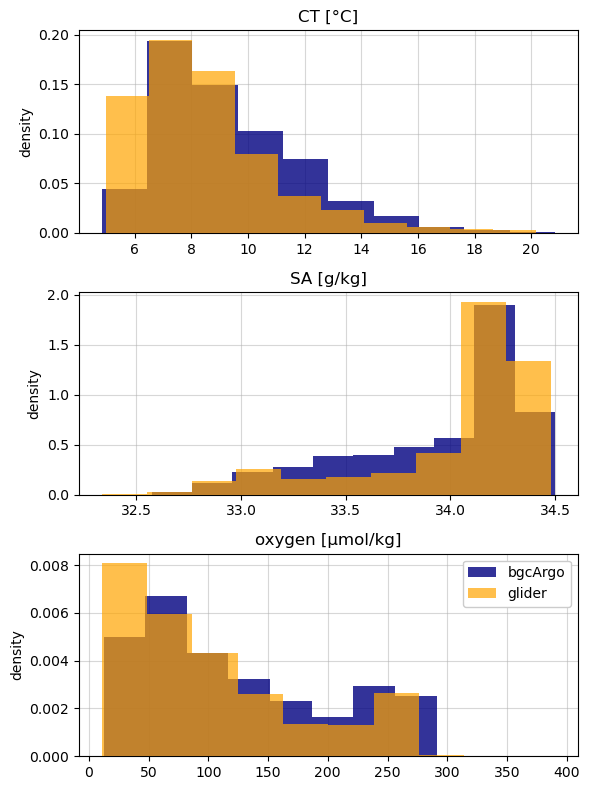

In [16]:
axs = mod_argo.overlay_distributions(argoDF_QC, glider_traj0, 
                               axvars = ['CT', 'SA', 'oxygen'], 
                               axunits = ['[°C]', '[g/kg]', '[µmol/kg]'],
                               labels=['bgcArgo', 'glider']);


**Note:** if the distributions for a given tracer are extremely different, that feature will not offer accurate predictive power for the intended application. Given sparse ocean coverage, some differences in the distributions may be unavoidable. 


### Preprocessing

Some algorithms require you to standardize the features to zero mean and unit variance. Categorial variables can also be encoded. [A number of preprocessing functions](https://scikit-learn.org/stable/modules/preprocessing.html) are included as part of scikit-learn. 

The regressor used in this demo, Random Forest, is tree-based and does not require standardization.

## 1.2 Splitting train/validation/test data

In a machine learning workflow, we need to define a set of observations for training and optimizing our model, and withhold another set to test the final selected model. 

During the main [cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html) (CV) step, models are trained iteratively using a subset of the data (a "fold") and validated on the remaining withheld observations. CV allows us to associate all available observations with an error from a model iteration trained without that sample. 


![Workflow schematic](https://cdn.aptech.com/www/uploads/2023/05/Blank-diagram-2-1.jpg)
<i>Image source: aptech</i>

### Reserving test data first

Independent test data should be reserved before training/validation so that we can get an independent estimate of error for the final chosen model. **The test data should not be considered at any point during model selection.**

One way to partition test data is to group the data by time (e.g. sample random years) and reserve one group before training/validation (e.g. [Fissler 2023](https://arxiv.org/pdf/2202.12780)). For this demo, we will withhold two years, 2016 and 2024, which give us relatively good coverage of the region and represent approximately 20% of the data. 

In [17]:
withhold_test_years = [2016, 2024]
trainval_data = argoDF_QC[(~argoDF_QC.year.isin(withhold_test_years))]
test_data = argoDF_QC[argoDF_QC.year.isin(withhold_test_years)]
pc_withheld = len(test_data.profid.unique()) / len(argoDF_QC.profid.unique()) * 100
print(str(np.round(pc_withheld,1)) + '% of profiles withheld for testing')

20.7% of profiles withheld for testing


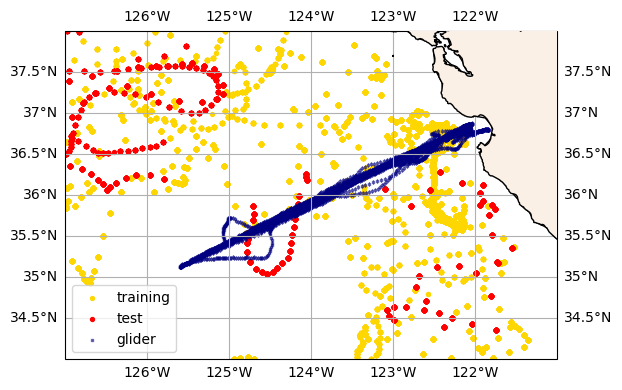

In [18]:
# Plot all data 
ax = mod_argo.map_study_region(gridlabel=True, ax_lims = box_lims) 
sca = ax.scatter(trainval_data.longitude, trainval_data.latitude, c='gold', s=8, transform=ccrs.PlateCarree(), 
                 label='training')
ax.scatter(test_data.longitude, test_data.latitude, c='red', s=8,  transform=ccrs.PlateCarree(), 
                 label='test')

ax.scatter(gliderINDEX.longitude, gliderINDEX.latitude, 
           s=2, alpha=0.5, marker='s', c='navy',
           transform=ccrs.PlateCarree(), label='glider')
ax.legend(loc='lower left', fontsize=10)

If available, using data from another platform (e.g. a different glider that did have nitrate) for independent testing would also be a good evaluation; this would give us a better idea of how the model, trained only on Argo data, will perform on observations from a different instrument. 

### Subsetting training/validation data


We use the sklearn implementation of `KFold` as the simplest random splitter (not recommended for final CV), then introduce three other forms:

1. by profile: shuffle the data by float profile
2. by WMO: shuffle the data by float (keep all profiles from one float together)
2. by [k-means clustering](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html): group the data using spatial coordinates, with optional zonal/meridional weighting (e.g. [Gregor et al. 2019](https://gmd.copernicus.org/articles/12/5113/2019/))


A visualization of random vs. spatial clustering: ![Kmeans](https://r.geocompx.org/images/12_partitioning.png)</br>
<i>Image source: geocompx</i>

We can use a simple custom class, `CrossValContainer`, to keep track of our training and validation data for each partition of the data. All three forms of splitting can be called using the function `populate_folds()`, which helps organize the different types of shuffling into a consistent format. 

There are many other ways to set up different types of splitters (e.g. Leave-One-Out, GroupKFold, RepeatedKFold), including [versions](https://machinelearningmastery.com/loocv-for-evaluating-machine-learning-algorithms/) without the need to write a separate Python class. Scikit-learn offers different CV implementations that you can explore in [more detail](https://scikit-learn.org/stable/api/sklearn.model_selection.html#splitters) alongside [visual examples of model selection](https://scikit-learn.org/stable/auto_examples/model_selection/plot_cv_indices.html#sphx-glr-auto-examples-model-selection-plot-cv-indices-py).

Although this notebook only explores spatially blocked CV, **time-based data splitting** is also an effective strategy for cross-validating ocean models. Examples include temporal hold out schemes in CSIR-ML6 ([Gregor et al. 2019](https://gmd.copernicus.org/articles/12/5113/2019/)), LDEO‐HPD ([Bennington et al. 2022](https://onlinelibrary.wiley.com/doi/abs/10.1029/2021MS002960)), and RFR-CCS ([Sharp et al. 2022](https://essd.copernicus.org/articles/14/2081/2022/)). 

In [19]:
# Set number of folds and initialize objects
nfolds = 5
fold_tags = ['fold' + str(i) for i in range(1, nfolds+1)]

# Random splitting (simple K-fold)
cvtainer_bySample = (mod_argo.CrossValContainer(trainval_data, nfolds)
                                .populate_folds({'type':'random'}))

# Splitting by platform (keep profiles from each float together)
cvtainer_byPlatform = (mod_argo.CrossValContainer(trainval_data, nfolds)
                                .populate_folds({'type':'platform',
                                                'indexer':'wmoid'}))

# Splitting by profile (keep data from different depths together)
# Note 'profid' is a unique string identifier (wmoid+cycle_number) per profile
cvtainer_byProfile = (mod_argo.CrossValContainer(trainval_data, nfolds)
                                .populate_folds({'type':'platform',
                                            'indexer':'profid'}))

### Fold Maps

The `CrossValContainer` class also has a function for quickly visualizing the training and validation splits called `.map_folds()`. Storing the plotting function in our module is a nice way to reuse plot code.

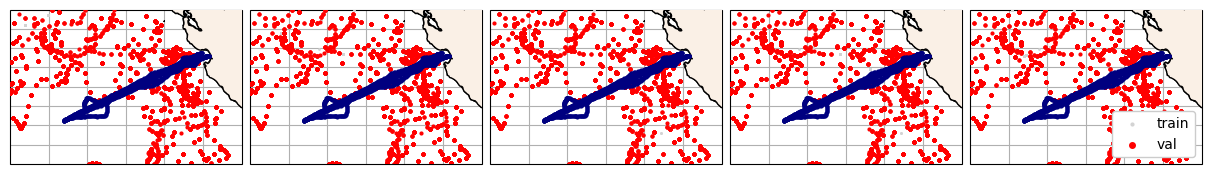

In [20]:
cvtainer_bySample.map_folds(glider_data = gliderINDEX);

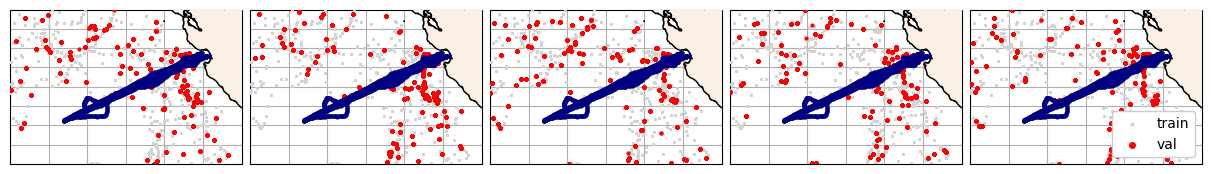

In [21]:
cvtainer_byProfile.map_folds(glider_data = gliderINDEX);

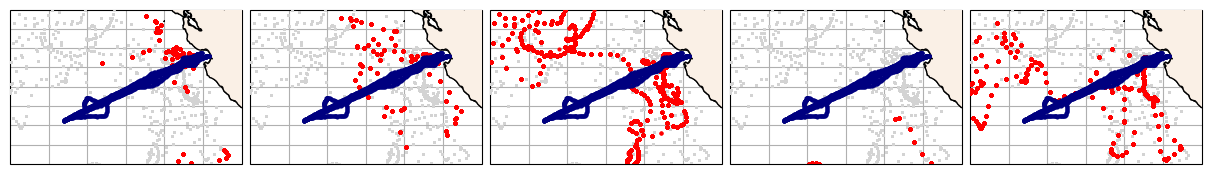

In [22]:
cvtainer_byPlatform.map_folds(glider_data = gliderINDEX, show_legend=False);

**Discussion:** comment on potential drawbacks behind each CV setup. With the same model/algorithm setup, do you expect one form of CV to return the lowest vs highest errors? 
</br></br></br></br>



**Code activity:** make a new CrossValContainer with k-means spatial clustering and map the folds. Hint: see `.subset_folds()` arguments in `argotools.py`



In [ ]:
# Add code here: 


# === Key === 
# cvtainer_byKmeans = (mod_argo.CrossValContainer(trainval_data, nfolds)
#                                 .populate_folds({'type':'kmeans',
#                                             'latitude_scaler':1}))
# cvtainer_byKmeans.map_folds(glider_data = gliderINDEX);


<div class="alert alert-block alert-info"> <b>Key idea:</b> The choice of training/validation/test data should be tailored to the intended application. There is no single cross-validation scheme that would be best for all applications. </div> 

- [Gray et al. 2024](https://tos.org/oceanography/article/the-promise-and-pitfalls-of-machine-learning-in-ocean-remote-sensing#:~:text=Accurate%20labels%20are%20often%20a,Time%20and%20Space%20Is%20Hard) "The Promise and Pitfalls of Machine Learning in Ocean Remote Sensing"
- [Sweet et al. 2024](https://journals.ametsoc.org/view/journals/aies/2/4/AIES-D-23-0026.1.xml) "Cross-Validation Strategy Impacts the Performance and Interpretation of Machine Learning Models"

# 2. Model training


This demo focuses on one algorithm, Random Forest (RF), which uses an ensemble of decision trees ("forest") to make estimates with reduced overfitting tendency ([Breiman et al. 2001](https://link.springer.com/article/10.1023/A:1010933404324)). RF incorporates randomness in two ways, by considering:
- a random subset of the data for each tree (bootstrapping)
- a random set of input features at each node of the tree </br>

![Random forest schematic](https://ars.els-cdn.com/content/image/1-s2.0-S2666449623000166-gr5.jpg)</br>
<i>Image source: [Chen and Bai 2023](sciencedirect.com/science/article/pii/S2666449623000166)</i>
</br>
________
</br>

In the next two subsections, we highlight two aspects of regression modeling:
1. Feature lists: what input variables does the model consider for estimating the target variable?
2. [Hyperparameters](https://towardsdatascience.com/parameters-and-hyperparameters-aa609601a9ac/): what algorithm architecture leads to the best performance?

Hyperparameters are variables that control the learning process; these are used by the algorithm when being trained but are not an explicit part of the final model. Some examples of hyperparameters include the number of estimators, learning rate, and maximum tree depth. **Different algorithms have different hyperparameters that can be tuned.** 

During error analysis, we'll also explore how the results change depending on the cross-validation setup. As we train models for each of the folds generated in the previous section, we can store results in the object `CrossValModelRun`, then write functions that act on this object to compare the errors. 

<div class="alert alert-block alert-warning"> <b>A warning against overfitting:</b> 
</br>
More flexible models can try to fit the errors (noise) on the training data too closely. Since the statistical properties of the training dataset are not fully representative, this can lead to overly optimistic validation errors when computed on in-sample data while returning poor performance on unseen data. 

- Spatiotemporal coordinate parameters (latitude, longitude, time) can increase overfitting tendency and should be used with caution
- Hyperparameters can adjust model flexibility; a larger ensemble can compensate for weaker, but less correlated individual learners
</div> 


- [Stock et al. 2022](https://www.sciencedirect.com/science/article/pii/S0924271622000648) "Spatiotemporal distribution of labeled data can bias the validation and selection of supervised learning algorithms: A marine remote sensing example"
- [Schratz et al. 2019](https://www.sciencedirect.com/science/article/pii/S0304380019302145) "Hyperparameter tuning and performance assessment of statistical and machine-learning algorithms using spatial data"

## 2.1 Comparing feature lists with K-fold CV

To determine what feature list to use, we use existing domain knowledge and start with input variables that are known to co-vary with the target. [Feature engineering](https://geo-smart.github.io/mlgeo-book/Chapter2-DataManipulation/2.11_feature_engineering.html) can also be used to generate other relevant inputs (statistical, temporal, spatial). 

Here, we'll explore the validation errors for five simple feature lists. Depending on the application, also consider incorporating atmospheric data (wind speed, sea level pressure) or satellite products (sea surface height, ocean color, sea ice).


In [24]:
# Set feature lists to iterate over 
feat_lists = [['CT', 'SA', 'pressure'],
              ['CT', 'SA', 'oxygen', 'pressure', 'sigma0'],
              ['CT', 'SA', 'oxygen', 'pressure', 'sigma0', 'latitude', 'longitude'],
              ['CT', 'SA', 'oxygen', 'pressure', 'sigma0', 'latitude', 'longitude', 'linear_time'], # add space/time
              ['CT', 'SA', 'oxygen', 'pressure', 'sigma0', 'latitude', 'longitude', 'ydcos', 'ydsin']] # add space/season

# Set run parameters and create "run tags" for the model iterations
target_variable = 'nitrate'
use_algorithm = 'RFR'
use_hyperparams = {'n_estimators': 100, # discussed in next section
                   'min_samples_split':10,
                   'max_features':3} 

# Create a dictionary of run options (here, by feature list)
feat_options, feat_tags = mod_argo.label_run_options(feat_lists) # Converts list to dictionary

# Initialize storage dictionary
# WARNING: Comment out below if running partial:
storedRuns_bySample = {runkey:{nfold:None for nfold in fold_tags} for runkey in feat_tags}
storedRuns_byProfile = {runkey:{nfold:None for nfold in fold_tags} for runkey in feat_tags}
storedRuns_byPlatform = {runkey:{nfold:None for nfold in fold_tags} for runkey in feat_tags}


**Note on the last feature list:** time of year, or season, is often a useful feature to include. The time of year is often encoded as two sinusoidal variables computed from the day of year (e.g. [GOBAI-O2](https://essd.copernicus.org/articles/15/4481/2023/) in Sharp et al. 2023, [OceanSODA](https://essd.copernicus.org/articles/13/777/2021/) in Gregor et al. 2021). Another proposed alternative is the cloud-free daily maximum theoretical [solar radiation](https://pypi.org/project/solarpy/) (Song et al., in prep), which has the benefit of keeping this temporal information as a single variable. 



In [25]:
# Iteratively train models and store results in a CrossValModelRun object for each feat_tags
for runkey in feat_tags[:]:
    storedRuns_bySample[runkey] = mod_argo.fit_cv_model(cvtainer_bySample, target_variable,
                                                use_feats = feat_options[runkey],
                                                use_algorithm = use_algorithm,
                                                use_hyperparams = use_hyperparams)

Fitting RFR...
Fitting RFR...
Fitting RFR...
Fitting RFR...
Fitting RFR...


In [26]:
for runkey in feat_tags[:]:
    storedRuns_byProfile[runkey] = mod_argo.fit_cv_model(cvtainer_byProfile, target_variable,
                                                use_feats = feat_options[runkey],
                                                use_algorithm = use_algorithm,
                                                use_hyperparams = use_hyperparams)

Fitting RFR...
Fitting RFR...
Fitting RFR...
Fitting RFR...
Fitting RFR...


In [27]:
for runkey in feat_tags[:]:
    storedRuns_byPlatform[runkey] = mod_argo.fit_cv_model(cvtainer_byPlatform, target_variable,
                                                use_feats = feat_options[runkey],
                                                use_algorithm = use_algorithm,
                                                use_hyperparams = use_hyperparams)
    


Fitting RFR...
Fitting RFR...
Fitting RFR...
Fitting RFR...
Fitting RFR...


**Code activity:** initialize storage + run the CV with k-means spatially clustered folds

In [ ]:
# Add code here: 



# === Key === 
# storedRuns_byKmeans = {runkey:{nfold:None for nfold in fold_tags} for runkey in feat_tags}
# for runkey in feat_tags[:]:
#     storedRuns_byKmeans[runkey] = mod_argo.fit_cv_model(cvtainer_byKmeans, target_variable,
#                                             use_feats = feat_options[runkey],
#                                             use_algorithm = use_algorithm,
#                                             use_hyperparams = use_hyperparams)


Since errors are stored by fold for each `CrossValModelRun` object, we can use the function `.collapse_errors()` to combine fold results into a single pandas Dataframe. 

In [29]:
# Example validation errors for a single run/feature list
storedRuns_bySample['featA'].collapse_errors().val_error

index
1445      0.241830
1457     -1.631278
1458     -1.889348
1459     -1.255617
1462     -0.763452
            ...   
360847   -2.293105
360850    0.105084
360854   -0.747581
360856    0.118114
360857   -0.329723
Name: val_error, Length: 24671, dtype: float64

**Code activity:** print the mean bias for each ModelRun (feature list) in storedRuns_byProfile. Hint: iterate over the feat_tags you used, and compute the value with np.mean() using the column 'val_error' as above.

In [ ]:
# Add code here: 


# === Key === 
# for tag in feat_tags: 
#     print(tag, np.mean(storedRuns_byProfile[tag].collapse_errors().val_error))


### Linear calibration

Model calibration is concerned with the question: when the model estimates X, does X happen on average? Note that a model returning a mean bias close to 0 is not necessarily well-calibrated since it may overpredict low values and underpredict high ones (e.g. [Fissler 2023](https://arxiv.org/pdf/2202.12780)). You can assess calibration visually by plotting the observed vs. estimated values, or the bias vs. estimated values. 

During the `fit_cv_model()` function call, we apply a simple linear calibration by fitting a line to the decile means for the estimates vs. the observations. You can retrieve the calibration coefficients (slope, intercept) as `CrossValModelRun.cal_coeffs`.

0.9975675210814648


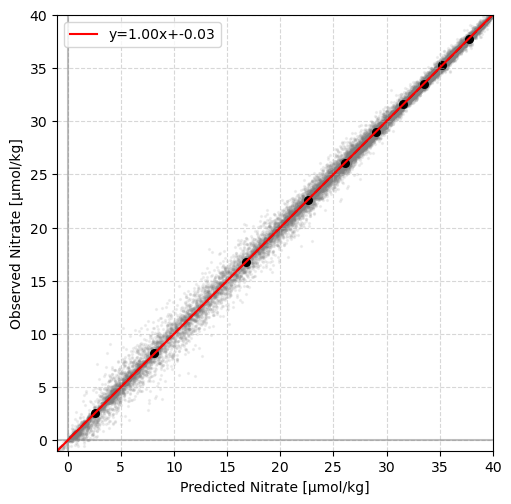

In [31]:
# Calibration plot
plot_data = storedRuns_bySample['featD'].collapse_errors()
ax = mod_argo.plot_decile_calibration(plot_data.val_prediction, plot_data[target_variable], axlims=[-1,40])
ax.set_ylabel('Observed Nitrate [µmol/kg]')
ax.set_xlabel('Predicted Nitrate [µmol/kg]')
print(r2_score(plot_data[target_variable], plot_data.val_prediction))


### Error Analysis

We can print a quick comparison of error metrics using the function `.storedRuns_comparison()`.

In [32]:
[print(k,v) for k,v in feat_options.items()]; print()
summary_bySample = mod_argo.storedRuns_comparison(storedRuns_bySample, error_param='lincal_error', show = True)

featA ['CT', 'SA', 'pressure']
featB ['CT', 'SA', 'oxygen', 'pressure', 'sigma0']
featC ['CT', 'SA', 'oxygen', 'pressure', 'sigma0', 'latitude', 'longitude']
featD ['CT', 'SA', 'oxygen', 'pressure', 'sigma0', 'latitude', 'longitude', 'linear_time']
featE ['CT', 'SA', 'oxygen', 'pressure', 'sigma0', 'latitude', 'longitude', 'ydcos', 'ydsin']

       median_AE   mean_AE          bias      RMSE
featA   0.414864  0.747597  1.483404e-07  1.177473
featB   0.279269  0.518599  8.732557e-07  0.837106
featC   0.220687  0.385485  2.469587e-06  0.624977
featD   0.195895  0.343119  2.594249e-06  0.557607
featE   0.199357  0.346758  3.069550e-06  0.557384


**Discussion**: Based on this CV by sample, what feature list would you use for your final model? Are the results definitive?
</br></br></br></br>

**Code activity:** compare results between the rest of the CV sets you ran (by sample, by profile, by k-means clustering) 

In [ ]:
# Add code here:


# === Key === 
# summary_byProfile = mod_argo.storedRuns_comparison(storedRuns_byProfile, 
#                                             error_param='lincal_error', show = True)
# summary_byPlatform= mod_argo.storedRuns_comparison(storedRuns_byPlatform, 
#                                             error_param='lincal_error', show = True)
# summary_byKmeans = mod_argo.storedRuns_comparison(storedRuns_byKmeans, 
#                                             error_param='lincal_error', show = True)


We can also map the errors and represent their dependence on depth:

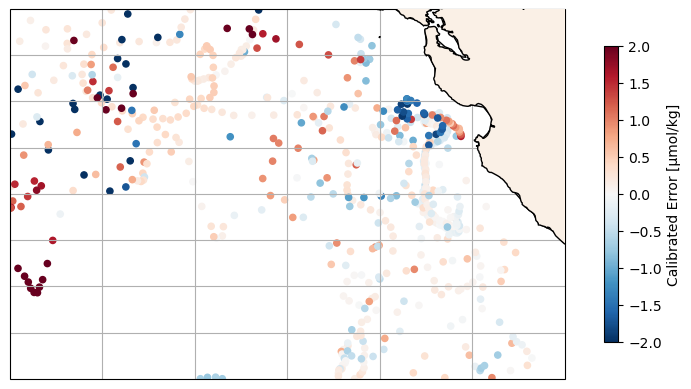

In [34]:
# Plot profile-averaged errors for chosen run
plot_data = storedRuns_byPlatform['featD'].average_profiles(calibrated=True)

ax = mod_argo.map_study_region() 
sca = ax.scatter(plot_data.longitude, plot_data.latitude, c=plot_data.lincal_error, s=20,  
           transform=ccrs.PlateCarree(), vmin=-2, vmax=2, cmap = 'RdBu_r')
plt.colorbar(sca, ax=ax, label='Calibrated Error [µmol/kg]', shrink=0.8)

**Discussion** Try plotting the errors for a few different runs. Do you notice any qualitative differences between the mapped errors depending on what features are included? On what type of CV you ran?
</br></br></br></br>

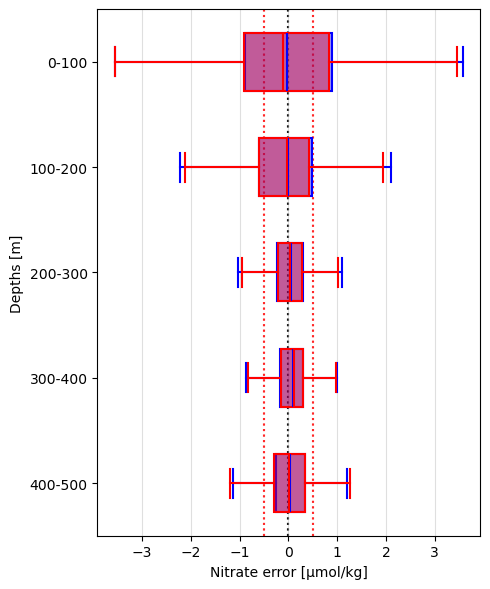

In [35]:
# Depth-binned boxplots comparing two different feature lists 

[ax, bplot] = mod_argo.boxplot_depth_binned(storedRuns_byPlatform['featC'].calibratedDF, plotvar='lincal_error',
                                            boxcolor='blue');
mod_argo.boxplot_depth_binned(storedRuns_byPlatform['featE'].calibratedDF, plotvar='lincal_error',
                              ax=ax, boxcolor='red');
ax.invert_yaxis()

**If extra time:** Make another plot of your choice exploring some aspect of the errors.

In [36]:
# Add code here:

**Discussion**: How do the errors change by CV setup, why do you think this might be the case? How should one select what type(s) of data splitting to perform?
</br></br></br></br>

<div class="alert alert-block alert-info"> <b>Key idea:</b> Completely random shuffling can return artificially low errors during validation given autocorrelation in the data. Incorporating at least one form of CV that considers geospatial correlation is recommended for ocean models. </div>

## 2.2 Exploring hyperparameters

During cross-validation, we can also tune the hyperparameters that control the machine learning architecture. This tuning is often automated using functions from sklearn (e.g. GridSearchCV, RandomSearchCV). There are also more sophisticated methods (e.g. [multivariate TPE sampling](https://dl.acm.org/doi/10.1145/3292500.3330701)) that can speed up the process when sampling a large parameter space. Some algorithms are more sensitive to hyperparameter tuning than others; Random Forest tends to offer good out-of-box performance while others like XGBoost may benefit more from tuning. 


Here, we won't perform full hyperparameter tuning (e.g. see nested cross-validation summarized in [Schratz et al. 2019](https://www.researchgate.net/publication/324150770_Performance_evaluation_and_hyperparameter_tuning_of_statistical_and_machine-learning_models_using_spatial_data)) as we would for a true application, but we can compare a few sets of selected hyperparameter options to highlight that these choices also affect performance.

In [37]:
# Set hyperparameter options to iterate over 
# These are translated into a dictionary before the fit_single_fold() call
hyperparam_tags = ['maxfeat3_minsplit10_nest500', # increase number estimators
                    'maxfeat3_minsplit2_nest100', # decrease minimum samples to split
                    'maxfeat3_minsplit2_nest500'] 
hyper_options, hyper_tags = mod_argo.label_run_options(hyperparam_tags, prefix='hyper') # Converts list to dictionary

# Set run parameters and feature lists
use_feat_list = feat_options['featE']
use_cvtainer = cvtainer_byProfile

**Activity:** look into the [RandomForestRegressor documentation](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html) in scikit-learn. What are some ways you can increase the complexity of each individual tree? In what cases would you want weaker individual learners? 

In [38]:
# Comment out if you want to store previous runs:
storedRuns_hyper = {runkey:{nfold:None for nfold in use_cvtainer.fold_list} for runkey in hyper_tags}

# Iterate over hyperparameter sets:
for runkey in hyper_tags[:]:
    use_hyperparams = mod_argo.expand_hyperparam_tag(hyper_options[runkey])
    storedRuns_hyper[runkey] = mod_argo.fit_cv_model(use_cvtainer, target_variable,
                                                use_feats = use_feat_list,
                                                use_algorithm = use_algorithm,
                                                use_hyperparams = use_hyperparams)
    

Fitting RFR...
Fitting RFR...
Fitting RFR...


**Discussion**: Which set of hyperparameters do you think will return the lowest validation errors? 

### Error analysis

In [39]:
summary_hyper = mod_argo.storedRuns_comparison(storedRuns_hyper, error_param='lincal_error', show = True)

        median_AE   mean_AE      bias      RMSE
hyperA   0.241975  0.442864  0.000003  0.715345
hyperB   0.235683  0.432623  0.000003  0.702755
hyperC   0.233142  0.429688  0.000003  0.699000


## 2.3 Final model training and testing

Once we've selected the algorithms/features that will work best, we can take advantage of the full training and validation dataset by re-training a final model using all available observations (other than the test data).


In [40]:
final_feats = ['CT', 'SA', 'oxygen', 'pressure', 'sigma0', 'latitude', 'longitude', 'ydcos', 'ydsin']
final_hyperparams = {}

[finalMdl, test_errors, test_cal_coeffs] = mod_argo.fit_test_final_model(trainval_data, test_data, 
                                var_predict = target_variable,
                                feat_list = final_feats,
                                regressor_type = use_algorithm,
                                hyperparams = final_hyperparams)
mod_argo.summarize_errors(test_errors, error_param='lincal_error', pd_format=True)

,median_abs_error,mean_abs_error,bias,rmse
,0.358284,0.604069,0.000019,0.931438


Note that the CV shuffled by sample would have given an overly optimistic estimate of error. 

In [41]:
summary_bySample

,median_AE,mean_AE,bias,RMSE
featA,0.414864,0.747597,1.483404e-07,1.177473
featB,0.279269,0.518599,8.732557e-07,0.837106
featC,0.220687,0.385485,2.469587e-06,0.624977
featD,0.195895,0.343119,2.594249e-06,0.557607
featE,0.199357,0.346758,3.069550e-06,0.557384


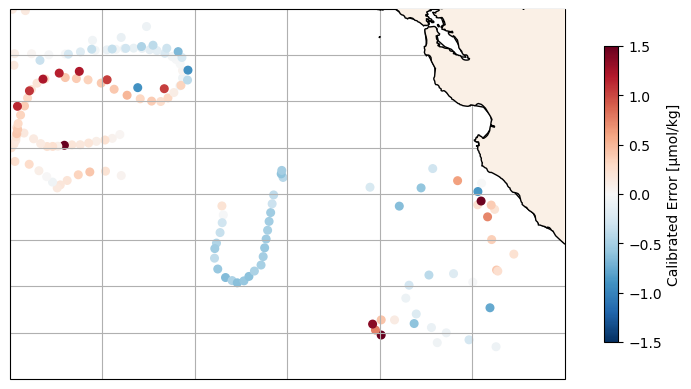

In [42]:
# Plot errors
ax = mod_argo.map_study_region() 
plot_data = test_errors.groupby('profid')[['latitude', 'longitude', 'lincal_error']].mean()
sca = ax.scatter(plot_data.longitude, plot_data.latitude, c=plot_data.lincal_error, s=30,  
           transform=ccrs.PlateCarree(), label='test', vmin=-1.5, vmax=1.5, cmap = 'RdBu_r')
plt.colorbar(sca, ax=ax, label='Calibrated Error [µmol/kg]', shrink=0.8)

**Discussion**: Based on the test errors, do you think your model will perform well on the glider application? What are some possible limitations? 

In [43]:
# Add other plots / analyses of errors as desired

# 3. Application to glider data

To save time, the features have already been calculated for the glider data. We can run the final model:

In [44]:
# Run the prediction 
glider_preds = mod_argo.apply_final_model(glider_traj0, 
                                          final_feats, finalMdl, test_cal_coeffs)
glider_preds.rename(columns={'prediction': 'nitrate_pred'}, inplace=True)
gliderINDEX = glider_preds.groupby('profile')

Since the glider traverses multiple times, you can also select a smaller range of time to see the nitrate gradient.

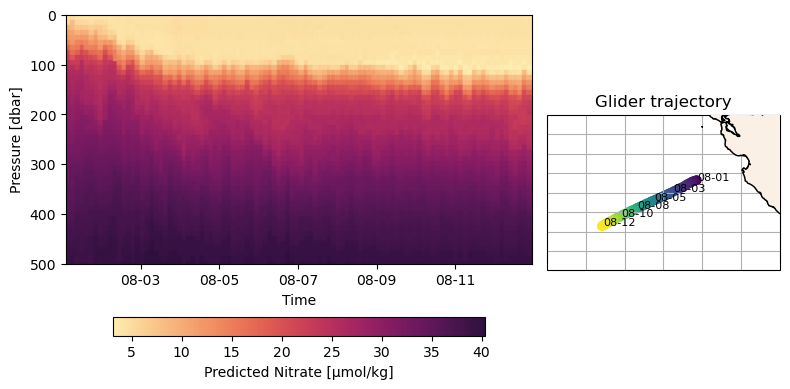

In [45]:
glid_subset = mod_argo.limit_datetime(glider_preds, min_time='2022-08-01', max_time='2022-08-13')
axs = mod_argo.plot_glider_predictions(glid_subset, label_dates=True);

To conclude, we can plot the predicted nitrate alongside the glider observations. 

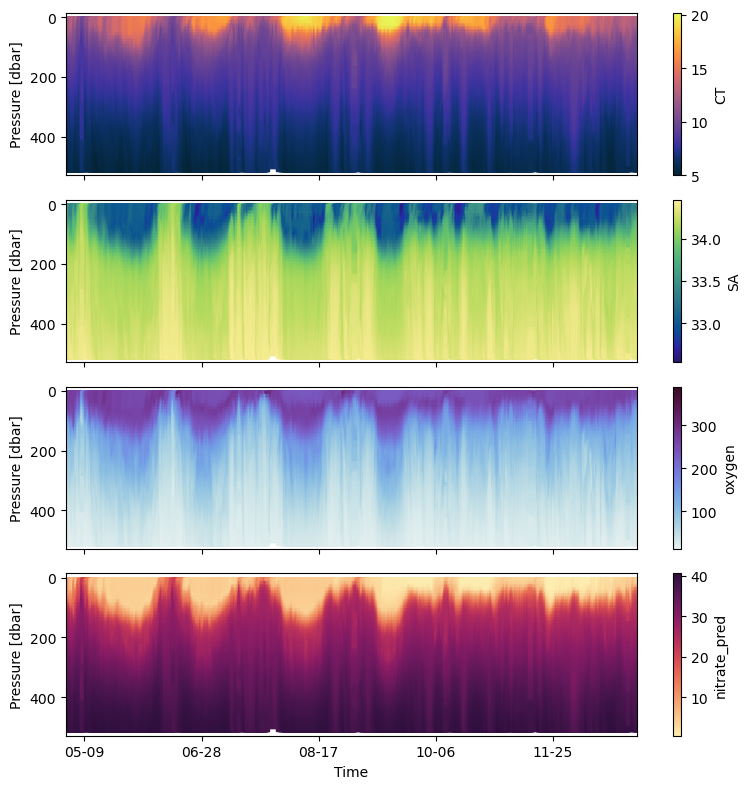

In [46]:
glid_subset = mod_argo.limit_datetime(glider_preds, min_time='2022-05-01', max_time='2022-12-31')
axs = mod_argo.plot_tracer_sections(glid_subset, axvars = ['CT', 'SA', 'oxygen', 'nitrate_pred'],
                     axpals = ['cmo.thermal', 'cmo.haline', 'cmo.dense', 'cmo.matter']);

In [47]:
# Add additional plots here: 

# 4. (Optional) Additional activities

For users with more experience, other options to explore:
- Add a different regressor option to the function `.fit_single_regressor` in mod_argo 
- Add a different data splitting strategy / try scikit-learn's native implementation (e.g. LeaveOneGroupOut)
- Add automated hyperparameter tuning in a nested CV strategy, as in [Schratz et al. 2019](https://www.researchgate.net/publication/324150770_Performance_evaluation_and_hyperparameter_tuning_of_statistical_and_machine-learning_models_using_spatial_data)

# 5. References + Resources

Textbooks:

- Online textbook from the UW course [Machine Learning in Geosciences (ESS659)](https://geo-smart.github.io/mlgeo-book/about_this_book/about_this_book.html)
- [Elements of Statistical Learning](https://hastie.su.domains/ElemStatLearn/), Hastie 2009



Coding:

- [scikit-learn Getting Started](https://scikit-learn.org/stable/getting_started.html)
- [Pytorch](https://docs.pytorch.org/tutorials/) for deep learning
- [Geocomputation for Python](https://py.geocompx.org/) 


Data Sources: 

- [Glider CUGN line 66](https://spraydata.ucsd.edu/projects/cugn/#about-project-dataset)
- Argo (2026). Argo float data and metadata from Global Data Assembly Centre (Argo GDAC). SEANOE. https://doi.org/10.17882/42182

These data were collected and made freely available by the International Argo Program and the national programs that contribute to it.  (https://argo.ucsd.edu,  https://www.ocean-ops.org).  The Argo Program is part of the Global Ocean Observing System. 
